In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [2]:
from variable_print import p,ps,pst

In [4]:
import tensorflow as tf
import keras
from keras.models import load_model
import tensorflow_probability as tfp
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore")

In [ ]:
%%time
%%capture
!apt-get install -y swig
!pip install gymnasium[box2d]

https://www.gymlibrary.dev/environments/box2d/lunar_lander/

In [9]:
import gymnasium as gym
env = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")
# env= gym.make("LunarLanderContinuous-v2")
state_low = env.observation_space.low
state_high = env.observation_space.high
action_low = env.action_space.low
action_high = env.action_space.high
print('1 :', state_low)
print('2 :', state_high)
print('3 :', action_low)
print('4 :', action_high)
env.close()

1 : [ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ]
2 : [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ]
3 : [-1. -1.]
4 : [1. 1.]


In [10]:
class RBuffer():
  def __init__(self, maxsize, statedim, naction):
    self.cnt = 0
    self.maxsize = maxsize
    self.state_memory = np.zeros((maxsize, *statedim), dtype=np.float32)
    self.action_memory = np.zeros((maxsize, naction), dtype=np.float32)
    self.reward_memory = np.zeros((maxsize,), dtype=np.float32)
    self.next_state_memory = np.zeros((maxsize, *statedim), dtype=np.float32)
    self.done_memory = np.zeros((maxsize,), dtype= np.bool)

  def storexp(self, state, next_state, action, done, reward):
    index = self.cnt % self.maxsize
    self.state_memory[index] = state
    self.action_memory[index] = action
    self.reward_memory[index] = reward
    self.next_state_memory[index] = next_state
    self.done_memory[index] = 1- int(done)
    self.cnt += 1

  def sample(self, batch_size):
    max_mem = min(self.cnt, self.maxsize)
    batch = np.random.choice(max_mem, batch_size, replace= False)
    states = tf.convert_to_tensor(self.state_memory[batch])
    next_states = tf.convert_to_tensor(self.next_state_memory[batch])
    rewards = tf.convert_to_tensor(self.reward_memory[batch])
    actions = tf.convert_to_tensor(self.action_memory[batch])
    dones = tf.convert_to_tensor(self.done_memory[batch],dtype=tf.float32)
    return states, next_states, rewards, actions, dones

In [11]:
class Critic(tf.keras.Model):
  def __init__(self):
    super(Critic, self).__init__()
    self.f1 = tf.keras.layers.Dense(512, activation='relu')
    self.f2 = tf.keras.layers.Dense(512, activation='relu')
    self.v =  tf.keras.layers.Dense(1, activation=None)

  def call(self, inputstate, action):
    x = self.f1(tf.concat([inputstate, action], axis=1))
    x = self.f2(x)
    x = self.v(x)
    return x

class Actor(tf.keras.Model):
  def __init__(self, no_action):
    super(Actor, self).__init__()
    self.f1 = tf.keras.layers.Dense(512, activation='relu')
    self.f2 = tf.keras.layers.Dense(512, activation='relu')
    self.mu =  tf.keras.layers.Dense(no_action, activation='tanh')

  def call(self, state):
    x = self.f1(state)
    x = self.f2(x)
    x = self.mu(x)
    return x

In [16]:
class Agent():
  def __init__(self, n_action= len(env.action_space.high)):
    self.actor_main = Actor(n_action)
    self.actor_target = Actor(n_action)
    self.critic_main = Critic()
    self.critic_target = Critic()
    self.actor_target.set_weights(self.actor_main.get_weights()) ##
    self.critic_target.set_weights(self.critic_main.get_weights()) ##

    self.a_opt = tf.keras.optimizers.Adam(1e-4)
    self.c_opt = tf.keras.optimizers.Adam(1e-4)
    self.memory = RBuffer(1_00_000, env.observation_space.shape, len(env.action_space.high))
    self.gamma = 0.99
    self.batch_size = 64
    self.tau = 1.0
    self.n_actions = len(env.action_space.high)
    self.min_action = env.action_space.low[0]
    self.max_action = env.action_space.high[0]

  def act(self, state, evaluate=False):
      state = tf.convert_to_tensor([state], dtype=tf.float32)
      actions = self.actor_main(state)
      if not evaluate:
          actions += tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=0.1)
          actions = self.max_action * (tf.clip_by_value(actions, self.min_action, self.max_action))
      return actions[0]

  def savexp(self,state, next_state, action, done, reward):
        self.memory.storexp(state, next_state, action, done, reward)

  # This update target parameters slowly
  def update_target(self, target_weights, weights, tau):
      for (a, b) in zip(target_weights, weights):
          a.assign(b * tau + a * (1 - tau))

  @tf.function
  def train(self, states, next_states, rewards, actions, dones):
      print("train")
      with tf.GradientTape() as tape1, tf.GradientTape() as tape2:

          target_actions = self.actor_target(next_states)
          target_next_state_values = tf.squeeze(self.critic_target(next_states, target_actions), 1)
          critic_value = tf.squeeze(self.critic_main(states, actions), 1)
          target_values = rewards + self.gamma * target_next_state_values * dones
          critic_loss = tf.keras.losses.MSE(target_values, critic_value)

          new_policy_actions = self.actor_main(states)
          actor_loss = -self.critic_main(states, new_policy_actions)
          actor_loss = tf.math.reduce_mean(actor_loss)

      grads1 = tape1.gradient(actor_loss, self.actor_main.trainable_variables)
      grads2 = tape2.gradient(critic_loss, self.critic_main.trainable_variables)
      self.a_opt.apply_gradients(zip(grads1, self.actor_main.trainable_variables))
      self.c_opt.apply_gradients(zip(grads2, self.critic_main.trainable_variables))
      return critic_loss, actor_loss

In [17]:
%%time
#env= gym.make("LunarLanderContinuous-v2")
agent = Agent()

episods = 10
ep_rewards = []
avg_rewards = []
losses = []
target = False
train_step = 0
replace = 5

for epis in range(episods):
  ep_reward = 0
  ep_step = 0
  done = False

  state, _ = env.reset()
  while not done:
    action = agent.act(state)
    next_state, reward, done, _, _ = env.step(action)
    agent.savexp(state, next_state, action, done, reward)
    state = next_state
    ep_reward += reward
    ep_step += 1
    if agent.memory.cnt > agent.batch_size:
      states, next_states, rewards, actions, dones = agent.memory.sample(agent.batch_size)
      losses.append(agent.train(states, next_states, rewards, actions, dones))
      train_step += 1
    if train_step % replace == 0:
      agent.update_target(agent.actor_target.variables, agent.actor_main.variables, agent.tau)
      agent.update_target(agent.critic_target.variables, agent.critic_main.variables, agent.tau)

    if done:
        ep_rewards.append(ep_reward)
        avg_rewards.append(np.mean(ep_rewards[-30:]))
        print(f"Episodes(steps):{epis:03d}({ep_step:03d}), Rewards(average):{ep_reward:3.1f}({avg_rewards[-1]:3.1f})",end="")
        last_losses = losses[-1]
        print(f',\t Loss:: Q:{last_losses[0]:.3f}, A:{last_losses[1]:.3f}',end="")
        print(f',\t Buffer.cnt:{agent.memory.cnt}')
  if avg_rewards[-1] >= 30:
    save_path = path+"models/DRL/DDPG_Lunar"
    agent.actor_main.save(save_path)
    break
# env.close()

train
train
Episodes(steps):000(119), Rewards(average):-96.0(-96.0),	 Loss:: Q:1.605, A:0.066,	 Buffer.cnt:119
Episodes(steps):001(091), Rewards(average):-693.3(-394.6),	 Loss:: Q:166.318, A:8.181,	 Buffer.cnt:210
Episodes(steps):002(092), Rewards(average):-227.2(-338.8),	 Loss:: Q:16.910, A:16.771,	 Buffer.cnt:302
Episodes(steps):003(081), Rewards(average):-685.4(-425.5),	 Loss:: Q:15.372, A:18.285,	 Buffer.cnt:383
Episodes(steps):004(087), Rewards(average):-482.3(-436.8),	 Loss:: Q:24.930, A:37.901,	 Buffer.cnt:470
Episodes(steps):005(071), Rewards(average):-108.1(-382.1),	 Loss:: Q:9.259, A:49.690,	 Buffer.cnt:541
Episodes(steps):006(071), Rewards(average):-150.8(-349.0),	 Loss:: Q:34.792, A:57.749,	 Buffer.cnt:612
Episodes(steps):007(068), Rewards(average):-152.9(-324.5),	 Loss:: Q:76.391, A:53.392,	 Buffer.cnt:680
Episodes(steps):008(081), Rewards(average):-116.9(-301.4),	 Loss:: Q:11.607, A:62.231,	 Buffer.cnt:761
Episodes(steps):009(070), Rewards(average):-101.6(-281.5),	 Loss::

In [ ]:
%%time
#env= gym.make("LunarLanderContinuous-v2")
agent = Agent()

episods = 300
ep_rewards = []
avg_rewards = []
losses = []
target = False
train_step = 0
replace = 5

for epis in range(episods):
  ep_reward = 0
  ep_step = 0
  done = False

  state, _ = env.reset()
  while not done:
    action = agent.act(state)
    next_state, reward, done, _, _ = env.step(action)
    agent.savexp(state, next_state, action, done, reward)
    state = next_state
    ep_reward += reward
    ep_step += 1
    if agent.memory.cnt > agent.batch_size:
      states, next_states, rewards, actions, dones = agent.memory.sample(agent.batch_size)
      losses.append(agent.train(states, next_states, rewards, actions, dones))
      train_step += 1
    if train_step % replace == 0:
      agent.update_target(agent.actor_target.variables, agent.actor_main.variables, agent.tau)
      agent.update_target(agent.critic_target.variables, agent.critic_main.variables, agent.tau)

    if done:
        ep_rewards.append(ep_reward)
        avg_rewards.append(np.mean(ep_rewards[-30:]))
        print(f"Episodes(steps):{epis:03d}({ep_step:03d}), Rewards(average):{ep_reward:3.1f}({avg_rewards[-1]:3.1f})",end="")
        last_losses = losses[-1]
        print(f',\t Loss:: Q:{last_losses[0]:.3f}, A:{last_losses[1]:.3f}',end="")
        print(f',\t Buffer.cnt:{agent.memory.cnt}')
  if avg_rewards[-1] >= 30:
    save_path = path+"models/DRL/DDPG_Lunar"
    agent.actor_main.save(save_path)
    break
# env.close()
# Wall time: 27min 7s

train
train
Episodes(steps):000(097), Rewards(average):-159.2(-159.2),	 Loss:: Q:156.225, A:1.054,	 Buffer.cnt:97
Episodes(steps):001(124), Rewards(average):-283.1(-221.1),	 Loss:: Q:238.652, A:11.542,	 Buffer.cnt:221
Episodes(steps):002(077), Rewards(average):-167.4(-203.2),	 Loss:: Q:1.551, A:23.667,	 Buffer.cnt:298
Episodes(steps):003(085), Rewards(average):-86.4(-174.0),	 Loss:: Q:38.348, A:35.482,	 Buffer.cnt:383
Episodes(steps):004(141), Rewards(average):-256.8(-190.6),	 Loss:: Q:49.999, A:57.795,	 Buffer.cnt:524
Episodes(steps):005(097), Rewards(average):-380.5(-222.2),	 Loss:: Q:19.478, A:61.480,	 Buffer.cnt:621
Episodes(steps):006(127), Rewards(average):-34.8(-195.5),	 Loss:: Q:3.838, A:68.642,	 Buffer.cnt:748
Episodes(steps):007(094), Rewards(average):-263.8(-204.0),	 Loss:: Q:13.322, A:71.033,	 Buffer.cnt:842
Episodes(steps):008(109), Rewards(average):-263.9(-210.7),	 Loss:: Q:4.308, A:68.209,	 Buffer.cnt:951
Episodes(steps):009(096), Rewards(average):-365.3(-226.1),	 Loss::

```python
Episodes(steps):000(097), Rewards(average):-159.2(-159.2),	 Loss:: Q:156.225, A:1.054,	 Buffer.cnt:97
Episodes(steps):005(097), Rewards(average):-380.5(-222.2),	 Loss:: Q:19.478, A:61.480,	 Buffer.cnt:621
Episodes(steps):010(125), Rewards(average):-245.6(-227.9),	 Loss:: Q:4.943, A:78.574,	 Buffer.cnt:1172
Episodes(steps):015(115), Rewards(average):-63.6(-189.0),	 Loss:: Q:1.732, A:65.174,	 Buffer.cnt:1702
Episodes(steps):020(100), Rewards(average):-64.1(-159.7),	 Loss:: Q:39.753, A:46.724,	 Buffer.cnt:2232
Episodes(steps):025(083), Rewards(average):-186.5(-168.2),	 Loss:: Q:34.776, A:37.567,	 Buffer.cnt:2727
Episodes(steps):030(118), Rewards(average):-306.0(-170.2),	 Loss:: Q:3.146, A:53.295,	 Buffer.cnt:3429
Episodes(steps):035(109), Rewards(average):-358.8(-187.9),	 Loss:: Q:3.558, A:48.682,	 Buffer.cnt:4069
Episodes(steps):040(179), Rewards(average):-108.6(-180.2),	 Loss:: Q:70.630, A:37.021,	 Buffer.cnt:4896
Episodes(steps):045(140), Rewards(average):-81.0(-180.9),	 Loss:: Q:11.000, A:44.565,	 Buffer.cnt:5510
Episodes(steps):050(102), Rewards(average):-25.2(-202.0),	 Loss:: Q:9.490, A:41.027,	 Buffer.cnt:6319
Episodes(steps):055(131), Rewards(average):-138.0(-188.0),	 Loss:: Q:36.984, A:24.467,	 Buffer.cnt:7042
Episodes(steps):060(146), Rewards(average):-129.4(-171.0),	 Loss:: Q:124.580, A:28.367,	 Buffer.cnt:7793
Episodes(steps):065(149), Rewards(average):-198.3(-141.9),	 Loss:: Q:162.303, A:35.238,	 Buffer.cnt:8564
Episodes(steps):070(261), Rewards(average):-151.8(-128.8),	 Loss:: Q:20.782, A:22.595,	 Buffer.cnt:9415
Episodes(steps):075(150), Rewards(average):-211.5(-137.0),	 Loss:: Q:4.690, A:-3.438,	 Buffer.cnt:11123
Episodes(steps):080(143), Rewards(average):-62.5(-128.2),	 Loss:: Q:12.842, A:-21.625,	 Buffer.cnt:11965
Episodes(steps):085(199), Rewards(average):-537.7(-157.7),	 Loss:: Q:31.566, A:-29.973,	 Buffer.cnt:12981
Episodes(steps):090(253), Rewards(average):-401.6(-194.1),	 Loss:: Q:35.695, A:-15.182,	 Buffer.cnt:13902
Episodes(steps):095(457), Rewards(average):217.9(-174.2),	 Loss:: Q:18.504, A:-12.228,	 Buffer.cnt:15055
Episodes(steps):100(162), Rewards(average):-7.8(-164.9),	 Loss:: Q:79.210, A:-21.285,	 Buffer.cnt:15985
Episodes(steps):105(245), Rewards(average):-97.1(-159.2),	 Loss:: Q:17.314, A:-30.237,	 Buffer.cnt:17241
Episodes(steps):110(239), Rewards(average):-20.1(-131.4),	 Loss:: Q:10.768, A:-42.128,	 Buffer.cnt:18777
Episodes(steps):115(209), Rewards(average):-22.3(-90.0),	 Loss:: Q:15.273, A:-66.598,	 Buffer.cnt:20162
Episodes(steps):120(172), Rewards(average):-244.7(-70.0),	 Loss:: Q:194.389, A:-43.075,	 Buffer.cnt:21182
Episodes(steps):125(163), Rewards(average):-88.3(-91.8),	 Loss:: Q:49.473, A:-57.539,	 Buffer.cnt:22955
Episodes(steps):130(204), Rewards(average):-52.2(-107.7),	 Loss:: Q:2.310, A:-51.365,	 Buffer.cnt:24647
Episodes(steps):135(334), Rewards(average):-141.2(-98.8),	 Loss:: Q:44.907, A:-59.627,	 Buffer.cnt:26506
Episodes(steps):140(427), Rewards(average):-202.4(-131.4),	 Loss:: Q:118.182, A:-43.886,	 Buffer.cnt:28423
Episodes(steps):145(318), Rewards(average):190.1(-118.8),	 Loss:: Q:15.151, A:-42.322,	 Buffer.cnt:30247
Episodes(steps):150(542), Rewards(average):180.7(-106.3),	 Loss:: Q:3.609, A:-47.132,	 Buffer.cnt:32099
Episodes(steps):155(275), Rewards(average):-34.1(-91.1),	 Loss:: Q:4.858, A:-52.039,	 Buffer.cnt:33806
Episodes(steps):160(519), Rewards(average):221.7(-67.5),	 Loss:: Q:25.892, A:-57.857,	 Buffer.cnt:35751
Episodes(steps):165(1000), Rewards(average):-207.7(-82.3),	 Loss:: Q:21.539, A:-64.559,	 Buffer.cnt:37823
Episodes(steps):170(294), Rewards(average):-394.1(-98.3),	 Loss:: Q:55.827, A:-75.133,	 Buffer.cnt:39857
Episodes(steps):175(254), Rewards(average):-94.0(-103.0),	 Loss:: Q:8.477, A:-105.689,	 Buffer.cnt:42162
Episodes(steps):180(342), Rewards(average):14.8(-99.3),	 Loss:: Q:204.517, A:-74.772,	 Buffer.cnt:44061
Episodes(steps):185(117), Rewards(average):-95.7(-84.6),	 Loss:: Q:24.660, A:-62.524,	 Buffer.cnt:46282
Episodes(steps):190(260), Rewards(average):-47.5(-98.4),	 Loss:: Q:8.150, A:-85.766,	 Buffer.cnt:49264
Episodes(steps):195(329), Rewards(average):198.4(-66.8),	 Loss:: Q:5.983, A:-68.793,	 Buffer.cnt:52005
Episodes(steps):200(1000), Rewards(average):-95.1(-36.8),	 Loss:: Q:2.400, A:-84.681,	 Buffer.cnt:55004
Episodes(steps):205(396), Rewards(average):215.1(-40.0),	 Loss:: Q:10.653, A:-71.908,	 Buffer.cnt:57237
Episodes(steps):210(703), Rewards(average):193.1(-24.8),	 Loss:: Q:14.000, A:-69.990,	 Buffer.cnt:60482
Episodes(steps):215(267), Rewards(average):-22.8(-31.0),	 Loss:: Q:4.333, A:-75.070,	 Buffer.cnt:62352
Episodes(steps):220(790), Rewards(average):-91.5(-26.6),	 Loss:: Q:64.487, A:-91.006,	 Buffer.cnt:65914
Episodes(steps):225(951), Rewards(average):119.0(-37.4),	 Loss:: Q:5.468, A:-83.669,	 Buffer.cnt:69750
Episodes(steps):230(938), Rewards(average):177.9(-28.3),	 Loss:: Q:16.355, A:-70.858,	 Buffer.cnt:74008
Episodes(steps):235(371), Rewards(average):171.5(-8.5),	 Loss:: Q:1.348, A:-72.513,	 Buffer.cnt:77577
Episodes(steps):240(1000), Rewards(average):-61.6(-11.7),	 Loss:: Q:8.791, A:-82.667,	 Buffer.cnt:80913
Episodes(steps):245(1000), Rewards(average):103.9(-2.8),	 Loss:: Q:6.486, A:-89.478,	 Buffer.cnt:85194
Episodes(steps):250(1000), Rewards(average):-66.7(17.7),	 Loss:: Q:13.449, A:-83.506,	 Buffer.cnt:89471
Episodes(steps):255(1000), Rewards(average):-35.5(19.6),	 Loss:: Q:161.137, A:-91.074,	 Buffer.cnt:92942
Episodes(steps):260(368), Rewards(average):-69.9(28.3),	 Loss:: Q:4.265, A:-88.323,	 Buffer.cnt:96238
Episodes(steps):265(516), Rewards(average):-111.8(11.5),	 Loss:: Q:23.372, A:-90.963,	 Buffer.cnt:100168
Episodes(steps):270(1000), Rewards(average):-23.7(1.8),	 Loss:: Q:7.796, A:-79.623,	 Buffer.cnt:103910
Episodes(steps):275(1000), Rewards(average):-19.4(0.8),	 Loss:: Q:14.683, A:-77.872,	 Buffer.cnt:106511
Episodes(steps):280(1000), Rewards(average):-49.9(-11.8),	 Loss:: Q:6.723, A:-77.692,	 Buffer.cnt:111167
Episodes(steps):285(705), Rewards(average):129.6(0.8),	 Loss:: Q:3.883, A:-68.170,	 Buffer.cnt:114789
Episodes(steps):290(935), Rewards(average):126.7(7.8),	 Loss:: Q:6.928, A:-74.151,	 Buffer.cnt:119153
Episodes(steps):295(980), Rewards(average):147.9(30.6),	 Loss:: Q:23.074, A:-71.676,	 Buffer.cnt:122371
Episodes(steps):299(898), Rewards(average):109.2(37.2),	 Loss:: Q:3.827, A:-71.449,	 Buffer.cnt:125388
```

In [18]:
def ma(a, n=50):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

np_losses = np.array(losses)

In [ ]:
# print(f'hidden_nodes:{256}, n_RM:{100000}, tau:{agent.tau}, \
#         a_lr:{Q_lr}, c_lr:{policy_lr}, alpha_lr:{alpha_lr}, BatchSize:{batch_size}, , multi_update:{multi_update}')

plt.figure(figsize=(10,3))
plt.subplot(121)

plt.plot(ep_rewards,label='reward')
plt.plot(avg_rewards,label='avg_reward')
plt.title("Reward")
plt.xlabel("Episods")
plt.ylabel("Total Reward")
plt.ylim(-500,300)
plt.grid()
plt.legend()

plt.subplot(122)
plt.plot(ma(np_losses[:,0]),label='loss_Q',linewidth=0.5)
plt.plot(ma(np_losses[:,1]),label='loss_A',linewidth=0.8)
plt.title("Loss")
plt.xlabel("Iterations")
plt.ylim(-110,200)
plt.grid()
plt.legend()
plt.show()
plt.show()

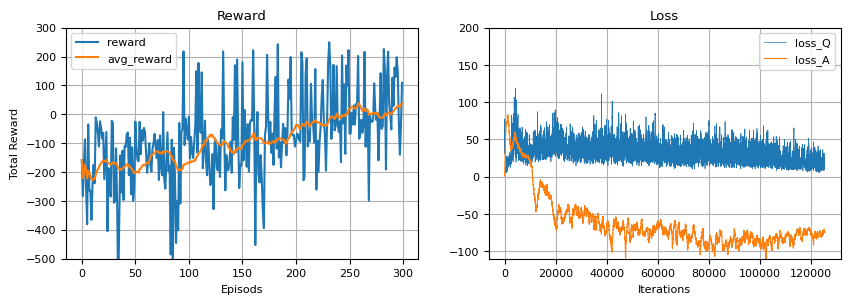

## Evaluation  

In [ ]:
### Save Model
#save_path = path+"models/DRL/DDPG_Lunar"
#agent.actor_main.save(save_path)

In [ ]:
### Load Model
# env= gym.make("LunarLanderContinuous-v2")
# agent = Agent()
# agent.actor_main = keras.models.load_model(save_path)

In [20]:
%%capture
!pip install pyvirtualdisplay
!apt-get install -y python-opengl ffmpeg
!apt install chromium-browser xvfb

In [21]:
from render import  show_video, wrap_env, render_as_image

In [22]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

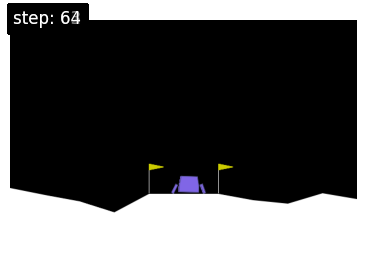

In [23]:
env_v = wrap_env(env, path=path, name_prefix="DDPG_Lunar")
state, _ = env_v.reset()
cnt = 0
done = False
while not done :
    render_as_image(env_v,step=cnt)
#    action = agent.act(state.reshape(-1,8), evaluate=True)
    action = agent.act(state, evaluate=True)
    state, reward, done, info, _ = env_v.step(action)
    cnt += 1
#    if cnt > 70 : break
env_v.close()

In [24]:
show_video(path=path,name_prefix='DDPG_Lunar')

/content/gdrive/MyDrive/Colab Notebooks/video/DDPG_Lunar-episode-0.mp4


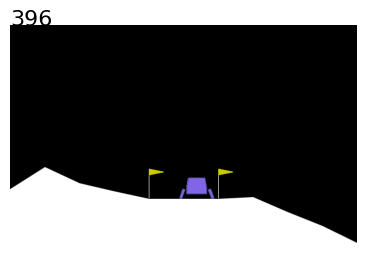

In [ ]:
env_v = wrap_env(env, path=path, name_prefix="DDPG_Lunar")
state, _ = env_v.reset()
cnt = 0
done = False
while not done :
    render_as_image(env_v,step=cnt)
#    action = agent.act(state.reshape(-1,8), evaluate=True)
    action = agent.act(state, evaluate=True)
    state, reward, done, info, _ = env_v.step(action)
    cnt += 1
env_v.close()

In [ ]:
show_video(path=path,name_prefix='DDPG_Lunar')

/content/gdrive/MyDrive/Colab Notebooks/video/DDPG_Lunar-episode-0.mp4
